# Analyze uncertainty for CD16-Mono (Loop 4)

Loads the optimized solutions, filters them, and checks heatmaps/clusters for the CD16Mono population.

In [1]:
from pathlib import Path
import copy
import math
import os
import sys

import fpsample
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy as sp
import seaborn as sns
import yaml
from matplotlib.colors import Normalize
from matplotlib.pyplot import rc_context
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import pdist
from tqdm import tqdm

sys.path.insert(0, "../../../../../../shared_utils")
from experiment_utils import manual_filtering

## Initialize columns to keep 

In [80]:
# Cell type fractions
celltype_fraction = {
    "CD16Mono": 0.02
}

columns_of_interest = [
    'gm-csf_[ng_ml]',
     'tpo_[ng_ml]',
     'sr1_[nm]',
     'um171_[nm]',
     'um729_[µm]',
     'scf_[ng_ml]',
     'butyzamide_[nm]',
     'retinoic_acid_[µm]',
     'ldl_[ng_ml]',
     'il3_[ng_ml]',
     'o2_[%]',
     'days_of_culture',
     'run_name',
     "cfg:constraints:c_scheduler_kwargs:t_warmup",
     "cfg:constraints:c_scheduler_kwargs:vmin",
     "cfg:constraints:c_scheduler_kwargs:vmax",

]

columns_of_interest_l4 =  columns_of_interest + ["il7_[ng_ml]",
                                                 "mcsf_[ng_ml]",
                                                 "ly_cocktail_[ul/well]", 
                                                 "loss", 
                                                 "target_ct_loss_std",
                                                 "target_ct_loss_mean",
                                                 "ct_prop_total_variance"]

## Load solutions 

In [81]:
def load_pure_cell_type_solutions(
    path_to_results,
    paths,
    cell_types,
    load_uncertainties=True
):

    path_to_results = Path(path_to_results)

    pure_cell_type_solution_dict = {
        cell_type: [] for cell_type in cell_types
    }

    for experiment_folder in tqdm(paths):

        cell_type_file_paths = path_to_results / experiment_folder

        if not cell_type_file_paths.exists():
            continue

        # Iterate through cell types
        for cell_type in os.listdir(cell_type_file_paths):

            if cell_type not in cell_types:
                continue

            config_exp_folders = cell_type_file_paths / cell_type

            if not config_exp_folders.is_dir():
                continue

            # Iterate through experiment configs
            for config_exp_folder in os.listdir(config_exp_folders):

                exp_folder = config_exp_folders / config_exp_folder

                if not exp_folder.is_dir():
                    continue

                # Check candidates.csv exists
                if "candidates.csv" not in os.listdir(exp_folder):
                    continue

                if load_uncertainties:
                    uncertainty_path = (
                        exp_folder
                        / "uncertainty_annotation"
                        / "candidates_with_uncertainties.csv"
                    )

                else:
                    uncertainty_path = (
                        exp_folder
                        / "candidates.csv"
                    )

                # Check uncertainty annotation exists
                if uncertainty_path.exists():
 
                    candidate_with_uncertainty_df = pd.read_csv(
                        uncertainty_path
                    )

                    candidate_with_uncertainty_df["run_name"] = [
                        Path(file).name
                        for file in candidate_with_uncertainty_df[
                            "cfg:paths:dump_dir"
                        ]
                    ]

                    pure_cell_type_solution_dict[cell_type].append(
                        candidate_with_uncertainty_df
                    )

    return pure_cell_type_solution_dict

## Read annotation file

In [82]:
# Read annotation files
ANNOTATION_CFG_FILE = "../../../../../../inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]
protocol_cols_l4 = protocol_cols + ['il7_[ng_ml]','mcsf_[ng_ml]','ly_cocktail_[ul/well]']

ANNOTATION_CFG_FILE_BOUNDS = "<INSERT PATH TO default_all_cols_loop4.yaml>"  # TODO: not found under inverse/loss_guidance/config/constraints/ - set to your own path
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound_l4 = yaml.safe_load(fb)
ubound_dict_l4, lbound_dict_l4 = annotation_cfg_bound_l4["ubound_dict"],  annotation_cfg_bound_l4["lbound_dict"]

bounds_l4 = {}
for param in lbound_dict_l4:
    bounds_l4[param] = (lbound_dict_l4[param], ubound_dict_l4[param])

### Collect optimized samples 

In [83]:
path_to_results_loop4 = Path("../../../../../../project_folder/output/inverse/loss_guidance/loop4_replicate")
paths_loop4 = os.listdir(path_to_results_loop4)

In [84]:
cell_types = ["CD16Mono"]

raw_solutions_loop4 = load_pure_cell_type_solutions(
    path_to_results_loop4,
    paths_loop4,
    cell_types,
    load_uncertainties=True
)

100%|██████████| 6/6 [00:04<00:00,  1.22it/s]


In [85]:
raw_solutions_loop4 = {
    key: pd.concat(val, axis=0) for key, val in raw_solutions_loop4.items()
}

In [86]:
cd16mono = raw_solutions_loop4['CD16Mono']

# Filter solutions

In [87]:
# Collect filtered and annotated data frames 
filtered_df_cd16mono, annotated_df_cd16mono = manual_filtering(
    df_dict={"CD16Mono": cd16mono},
    bounds=bounds_l4,
    columns_to_keep=columns_of_interest_l4, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=1, 
    protocol_cols=protocol_cols_l4,
    use_fraction_filter=True, 
    use_oxygen_days_filter=True,
    use_bounds_filter=False
)
cd16mono = filtered_df_cd16mono["CD16Mono"].reset_index()

In [88]:
cd16mono = cd16mono[cd16mono["days_of_culture"] < 18]

## Check heatmaps

In [89]:
cd16mono_prot = np.log1p(cd16mono.loc[:, protocol_cols_l4])
cd16mono_prop = cd16mono["CD16Mono_prop"]

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


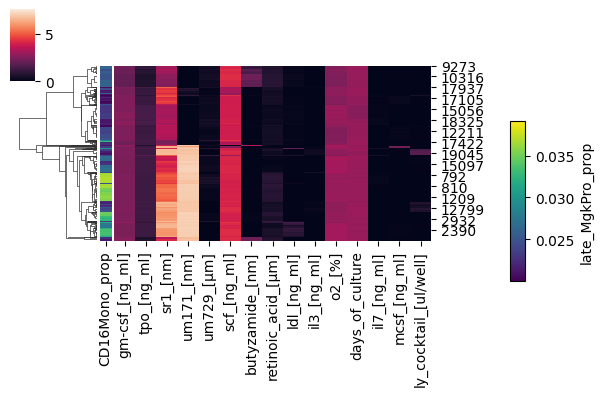

In [90]:
# Map the proportion values to colors using a continuous colormap
norm = Normalize(vmin=cd16mono_prop.min(), vmax=cd16mono_prop.max())
cmap = cm.viridis  # choose any colormap you like, e.g. "coolwarm", "magma"
row_colors = cd16mono_prop.map(lambda x: cmap(norm(x)))

g = sns.clustermap(
    cd16mono_prot,
    row_cluster=True,
    col_cluster=False,
    row_colors=row_colors,
    figsize=(5, 4),
)

# Add a separate colorbar legend for the row_colors annotation
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = g.fig.add_axes([1.02, 0.3, 0.03, 0.4])  # [left, bottom, width, height]
g.fig.colorbar(sm, cax=cbar_ax, label="late_MgkPro_prop")

plt.show()

In [91]:
# 1. Get the linkage used for the row dendrogram
row_linkage = g.dendrogram_row.linkage

# 2. Cut the tree into k clusters (tune this by eye from the dendrogram)
n_clusters = 4
row_clusters = fcluster(row_linkage, t=n_clusters, criterion='maxclust')

# 3. Build a dataframe linking each row (sample) to its cluster + its proportion value
cluster_df = pd.DataFrame({
    'cluster': row_clusters,
    'cd16mono_prop': cd16mono_prop.values
}, index=cd16mono_prot.index)

# 4. Check which cluster(s) have the highest average proportion
cluster_summary = cluster_df.groupby('cluster')['cd16mono_prop'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print(cluster_summary)

# 5. Pull out the actual samples in the top cluster(s)
top_cluster_id = cluster_summary.index[0]
high_prop_samples = cluster_df[cluster_df['cluster'] == top_cluster_id]
print(high_prop_samples)

             mean  count
cluster                 
3        0.034466     10
4        0.029645   2384
1        0.023569   2016
2        0.021688     12
      cluster  cd16mono_prop
1028        3       0.036201
1743        3       0.035134
1749        3       0.035126
1997        3       0.034648
2081        3       0.034248
2152        3       0.034098
2163        3       0.034044
2207        3       0.033884
2264        3       0.033674
2273        3       0.033603


Check if clusters are the ones we think

## Cluster 1

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


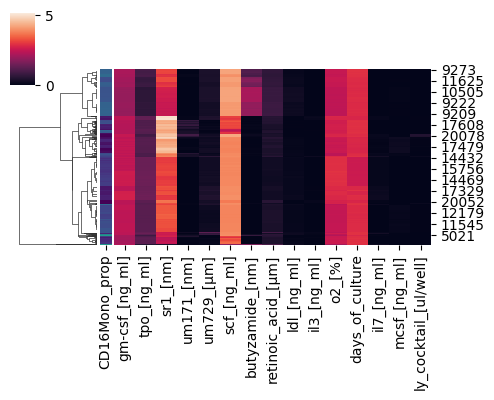

In [92]:
cd16mono_cl1 = cd16mono.loc[cluster_df[cluster_df.cluster==1].index]

sns.clustermap(
    np.log1p(cd16mono_cl1.loc[:, protocol_cols_l4]),
    row_cluster=True,
    col_cluster=False,
    row_colors=row_colors,
    figsize=(5, 4),
)

In [93]:
cd16mono_cl1_select = cd16mono_cl1.sort_values(by="target_ct_loss_std", ascending=True).iloc[:2]
cd16mono_cl1_select = pd.concat([cd16mono_cl1_select, cd16mono_cl1.iloc[[cd16mono_cl1["butyzamide_[nm]"].argmax()]]])
# cd16mono_cl1_select.to_csv("../../../../../../project_folder/output/inverse/loss_guidance/manually_filtered/cluster_analysis_loop4/cd16mono/cl1.csv")

In [94]:
cd16mono_cl1_select.loc[:, protocol_cols_l4]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well]
14261,12.423160,3.209113,19.328564,0.000000,0.294615,48.013560,0.000000,0.208946,0.127709,0.000000,17.431854,12.393672,0.068936,0.0,0.000000
9122,9.031258,2.235672,66.528854,0.333345,0.034107,10.521088,0.007013,0.565205,0.000600,0.032205,13.091718,17.432364,0.000000,0.0,0.006244
6377,20.388998,0.022046,0.000000,0.000000,0.000000,0.596516,38.535023,2.561072,0.078405,0.000000,10.049705,16.173895,0.269811,0.0,0.000000


## Cluster 2

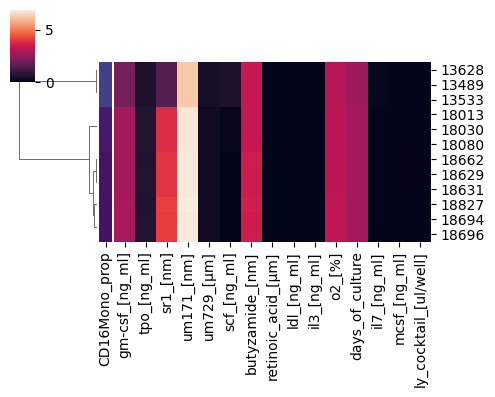

In [95]:
cd16mono_cl2 = cd16mono.loc[cluster_df[cluster_df.cluster==2].index]

sns.clustermap(
    np.log1p(cd16mono_cl2.loc[:, protocol_cols_l4]),
    row_cluster=True,
    col_cluster=False,
    row_colors=row_colors,
    figsize=(5, 4),
)

In [96]:
cd16mono_cl2_select = cd16mono_cl2.sort_values(by="target_ct_loss_std", ascending=True).iloc[:3]


cd16mono_cl2_select.loc[:, protocol_cols_l4]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well]
18631,15.436955,0.865069,51.365482,888.44946,0.343459,0.000000,30.234740,0.0,0.0,0.0,23.593918,15.224503,0.0,0.038605,0.028724
18030,15.200306,0.868115,43.279797,870.04810,0.357852,0.088406,27.029417,0.0,0.0,0.0,23.162292,15.099947,0.0,0.048512,0.026706
18696,15.788477,0.885804,57.598816,922.26880,0.351730,0.000000,30.980917,0.0,0.0,0.0,23.916172,15.429515,0.0,0.023536,0.026434


In [97]:
# cd16mono_cl2_select.to_csv("../../../../../../project_folder/output/inverse/loss_guidance/manually_filtered/cluster_analysis_loop4/cd16mono/cl2.csv")

## Cluster 3

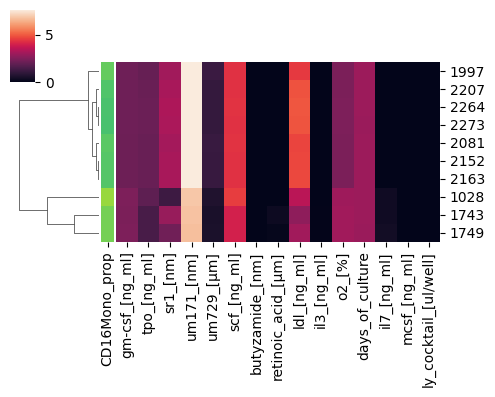

In [98]:
cd16mono_cl3 = cd16mono.loc[cluster_df[cluster_df.cluster==3].index]

sns.clustermap(
    np.log1p(cd16mono_cl3.loc[:, protocol_cols_l4]),
    row_cluster=True,
    col_cluster=False,
    row_colors=row_colors,
    figsize=(5, 4),
)

In [99]:
cd16mono_cl3_select = cd16mono_cl3.sort_values(by="target_ct_loss_std", ascending=True).iloc[:3]
cd16mono_cl3_select.loc[:, protocol_cols_l4]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well]
2273,7.474411,6.953814,23.762646,1947.89800,1.863672,74.058140,0.000000,0.000000,130.759660,0.000000,10.065598,17.465820,0.000000,0.000000,0.0
1749,10.266761,3.258072,7.696297,826.42816,0.753639,50.560566,0.013543,0.095796,19.787699,0.055803,19.971388,17.742868,0.466055,0.000000,0.0
2264,7.470041,6.956251,24.417831,1961.17640,1.887542,74.490160,0.000000,0.000000,132.684430,0.000000,10.067949,17.997576,0.000000,0.001295,0.0


In [100]:
# cd16mono_cl3_select.to_csv("../../../../../../project_folder/output/inverse/loss_guidance/manually_filtered/cluster_analysis_loop4/cd16mono/cl3.csv")

## Cluster 4

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


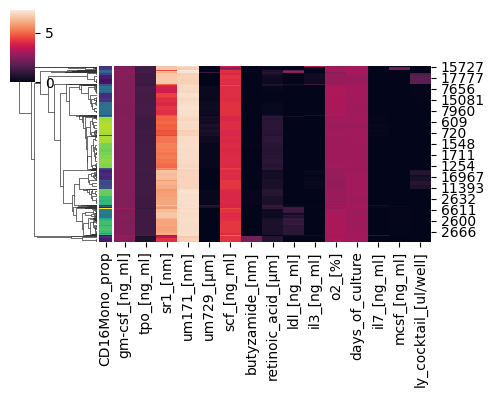

In [101]:
cd16mono_cl4 = cd16mono.loc[cluster_df[cluster_df.cluster==4].index]

sns.clustermap(
    np.log1p(cd16mono_cl4.loc[:, protocol_cols_l4]),
    row_cluster=True,
    col_cluster=False,
    row_colors=row_colors,
    figsize=(5, 4),
)

In [102]:
cd16mono_cl4_select = cd16mono_cl4.sort_values(by="target_ct_loss_std", ascending=True).iloc[:2]
cd16mono_cl4_select = pd.concat([cd16mono_cl4_select, cd16mono_cl4.iloc[[cd16mono_cl4["mcsf_[ng_ml]"].argmax()]]], axis=0)
cd16mono_cl4_select.loc[:, protocol_cols_l4]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well]
2683,9.967178,2.349695,390.85428,1079.0140,0.0,66.680070,0.000000,0.653935,1.281262,0.000000,20.673811,16.559290,0.017648,0.080714,0.000000
11325,10.456952,2.456211,424.21265,925.8682,0.0,64.940180,0.000000,0.657091,0.000000,0.120913,14.123379,17.918820,0.011143,0.001769,0.762883
18120,9.321890,2.383208,520.37010,1165.6693,0.0,41.997932,0.076558,0.000000,0.189275,0.000000,16.478548,15.469239,0.000000,10.001572,0.000000


In [103]:
# cd16mono_cl4_select.to_csv("../../../../../../project_folder/output/inverse/loss_guidance/manually_filtered/cluster_analysis_loop4/cd16mono/cl4.csv")

## PCA with clusters

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/tmp/ipykernel_2388132/1347226770.py:35: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(


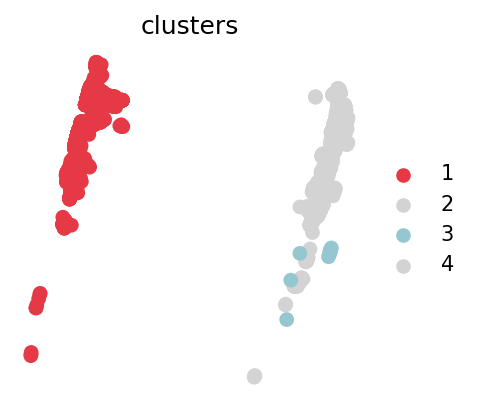

/tmp/ipykernel_2388132/1347226770.py:44: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(


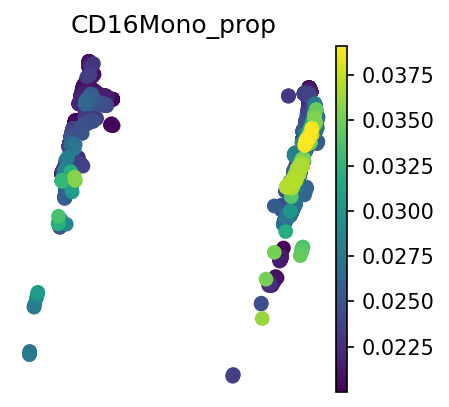

In [104]:
import scanpy as sc

sc.settings.figdir = "./plots"

with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": 150}):
    X_l4 = cd16mono_prot.values
    adata_l4 = sc.AnnData(X=X_l4.copy(), obs=cd16mono)
    adata_l4.obs["clusters"] = row_clusters
    adata_l4.obs["clusters"] = adata_l4.obs["clusters"].astype("category")
    sc.pp.pca(adata_l4)

    cluster_palette = {
        1: "#E63946",
        2: "lightgray",
        3: "#94C7CF",
        4: "lightgray",
        5: "lightgray",
    }
    cats = adata_l4.obs["clusters"].cat.categories
    if cats.dtype == object or all(isinstance(c, str) for c in cats):
        cluster_palette = {str(k): v for k, v in cluster_palette.items()}

    all_colors = {c: "#CCCCCC" for c in cats}
    all_colors.update(cluster_palette)

    # --- Reorder points so colored clusters (1, 3) are plotted last (on top) ---
    highlight_keys = [1, 3]
    if cats.dtype == object or all(isinstance(c, str) for c in cats):
        highlight_keys = [str(k) for k in highlight_keys]

    is_highlight = adata_l4.obs["clusters"].isin(highlight_keys)
    plot_order = adata_l4.obs_names[~is_highlight].tolist() + adata_l4.obs_names[is_highlight].tolist()
    adata_l4 = adata_l4[plot_order].copy()

    sc.pl.pca(
        adata_l4,
        s=200,
        color="clusters",
        frameon=False,
        groups=list(cluster_palette.keys()),
        palette=all_colors,
        save="_cd16mono_clusters.png",
    )
    sc.pl.pca(
        adata_l4,
        s=200,
        color="CD16Mono_prop",
        frameon=False,
        save="_cd16mono_prop.png",
    )

## Plots to save

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/tmp/ipykernel_2388132/251373283.py:26: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(


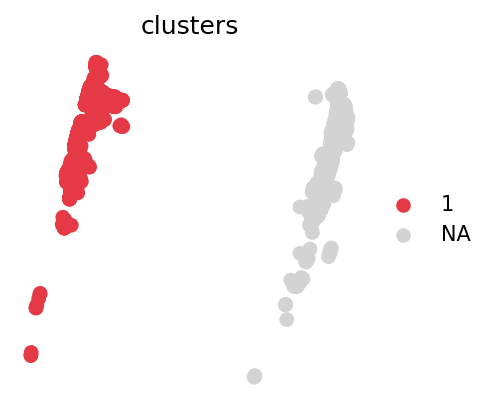

/tmp/ipykernel_2388132/251373283.py:26: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(


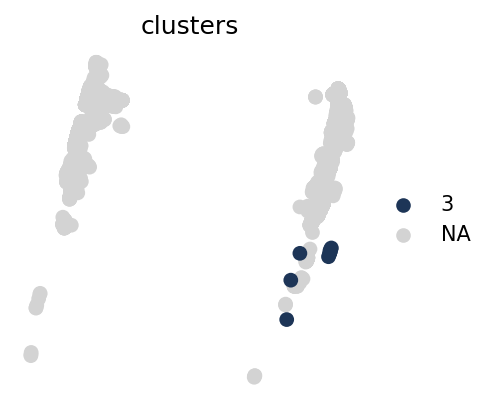

/tmp/ipykernel_2388132/251373283.py:26: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(


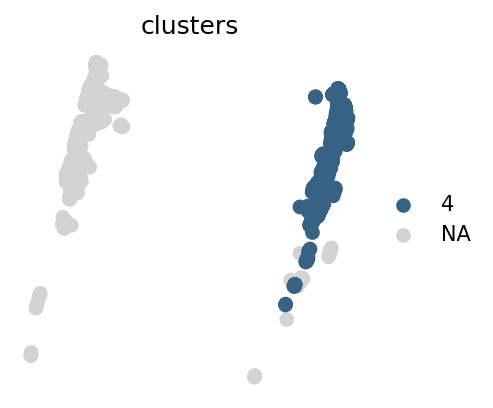

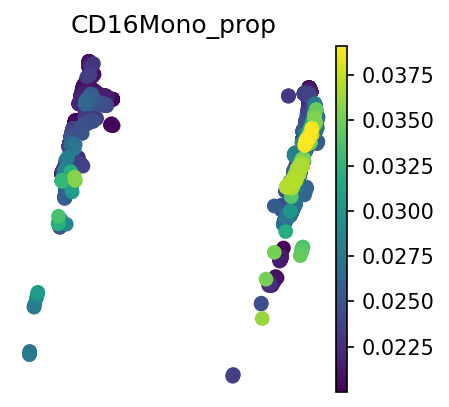

In [105]:
with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": 150}):
    X_l4 = cd16mono_prot.values
    adata_l4 = sc.AnnData(X=X_l4.copy(), obs=cd16mono)
    adata_l4.obs["clusters"] = row_clusters
    adata_l4.obs["clusters"] = adata_l4.obs["clusters"].astype("category")

    sc.pp.pca(adata_l4)

    # Make sure the palette keys match the actual category dtype (str vs int)
    cluster_palette = {
        1: "#E63946",
        # 2: "#ea7f83",
        3: "#1D3557",
        4: "#376284",
        # 5: "#94C7CF",
    }
    cats = adata_l4.obs["clusters"].cat.categories
    if cats.dtype == object or all(isinstance(c, str) for c in cats):
        cluster_palette = {str(k): v for k, v in cluster_palette.items()}

    # Option A: keep all points, give every category a color
    all_colors = {c: "#CCCCCC" for c in cats}  # fallback grey for other clusters
    all_colors.update(cluster_palette)

    for cl in cluster_palette:
        sc.pl.pca(
            adata_l4,
            s=200,
            color="clusters",
            frameon=False,
            groups=[cl],
            palette=all_colors,
            save=f"cd16mono_prop_cl_{cl}.png"
        )

    sc.pl.pca(adata_l4, s=200, color="CD16Mono_prop", frameon=False)

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


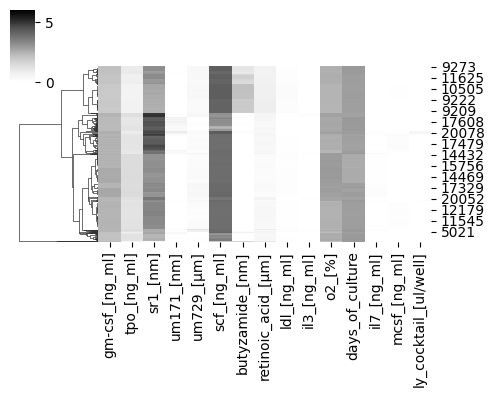

In [106]:
cd16mono_cl1 = cd16mono.loc[cluster_df[cluster_df.cluster==1].index]

g = sns.clustermap(
    np.log1p(cd16mono_cl1.loc[:, protocol_cols_l4]),
    row_cluster=True,
    col_cluster=False,
    cmap="Grays",
    figsize=(5, 4),
    vmax=6
)

g.savefig("plots/cd16mono_cl1.png", dpi=300, bbox_inches="tight")

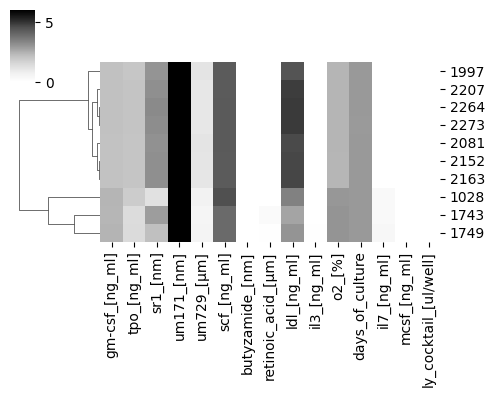

In [107]:
cd16mono_cl3 = cd16mono.loc[cluster_df[cluster_df.cluster==3].index]

g = sns.clustermap(
    np.log1p(cd16mono_cl3.loc[:, protocol_cols_l4]),
    row_cluster=True,
    col_cluster=False,
    cmap="Grays",
    figsize=(5, 4),
    vmax=6
)

g.savefig("plots/cd16mono_cl3.png", dpi=300, bbox_inches="tight")

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


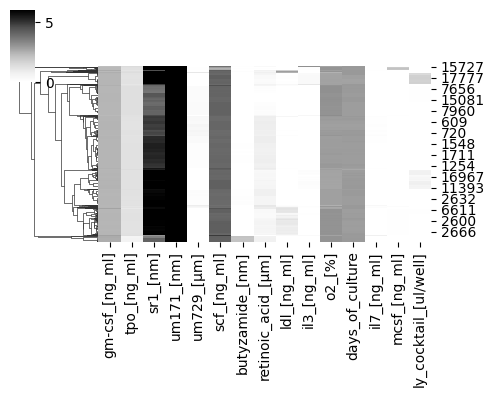

In [108]:
cd16mono_cl4 = cd16mono.loc[cluster_df[cluster_df.cluster==4].index]

g = sns.clustermap(
    np.log1p(cd16mono_cl4.loc[:, protocol_cols_l4]),
    row_cluster=True,
    col_cluster=False,
    cmap="Grays",
    figsize=(5, 4),
    vmax=6
)

g.savefig("plots/cd16mono_cl4.png", dpi=300, bbox_inches="tight")

## Plot pca and heagtmap

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/tmp/ipykernel_2388132/4003575721.py:25: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(


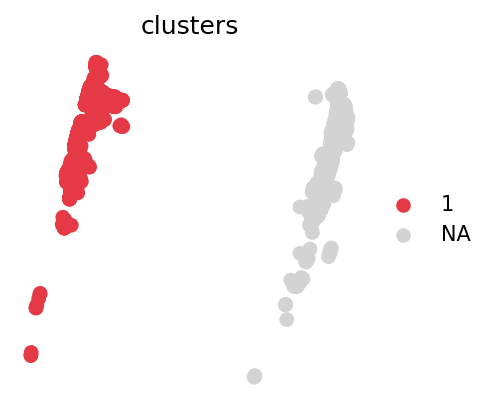

/tmp/ipykernel_2388132/4003575721.py:25: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(


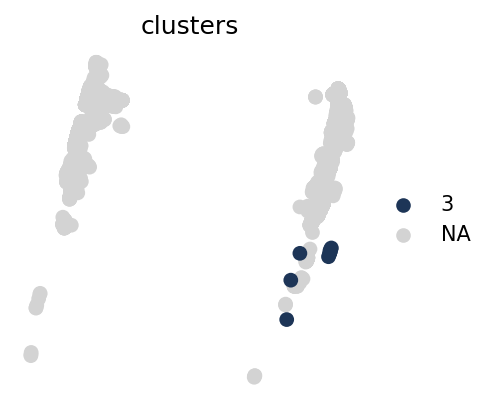

/tmp/ipykernel_2388132/4003575721.py:25: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca(


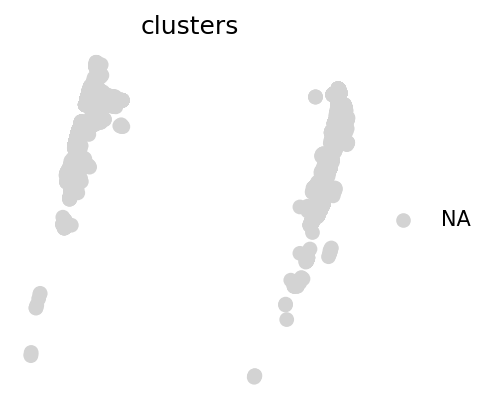

In [109]:
with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": 150}):
    X_l4 = cd16mono_prot.values
    adata_l4 = sc.AnnData(X=X_l4.copy(), obs=cd16mono_prot)
    adata_l4.obs["clusters"] = row_clusters
    adata_l4.obs["clusters"] = adata_l4.obs["clusters"].astype("category")

    sc.pp.pca(adata_l4)

    # Make sure the palette keys match the actual category dtype (str vs int)
    cluster_palette = {
        1: "#E63946",
        3: "#1D3557",
        5: "#94C7CF",
    }
    cats = adata_l4.obs["clusters"].cat.categories
    if cats.dtype == object or all(isinstance(c, str) for c in cats):
        cluster_palette = {str(k): v for k, v in cluster_palette.items()}

    # Give every category a color so scanpy's internal palette build doesn't KeyError
    all_colors = {c: "#CCCCCC" for c in cats}  # fallback grey for other clusters
    all_colors.update(cluster_palette) 
    
    for cl in cluster_palette:

        sc.pl.pca(
            adata_l4,
            s=200,
            color="clusters",
            frameon=False,
            groups=[cl],
            palette=all_colors,
            save=f"late_CD16Mono_prop_cl_{cl}.png"
        )

In [ ]:
# --- Parameters ---
n_top = 15

# --- Filter to clusters of interest ---
sub = cluster_df[cluster_df.cluster.isin([1, 3])]

# --- Keep top N rows per cluster, ranked by cd16mono_prop ---
top_idx = (
    sub.groupby("cluster")["cd16mono_prop"]
    .apply(lambda s: s.nlargest(n_top))
    .index.get_level_values(1)
)

# Sanity check
print("Original counts per cluster:")
print(sub.groupby("cluster").size())
print("\nCounts selected per cluster:")
print(sub.loc[top_idx].groupby("cluster").size())

# --- Subset the data matrix ---
cd16mono_cls = cd16mono.loc[top_idx]
print(f"\nSelected {len(cd16mono_cls)} rows out of {len(sub)} total")

# --- Plot ---
g = sns.clustermap(
    np.log1p(cd16mono_cls.loc[:, protocol_cols_l4]),
    row_cluster=True,
    col_cluster=False,
    cmap="Grays",
    figsize=(5, 4),
    vmax=6
)

g.savefig("plots/cd16mono_top15_per_cluster.png", dpi=300, bbox_inches="tight")

Original counts per cluster:
cluster
1    2016
3      10
dtype: int64

Counts selected per cluster:
cluster
1    15
3    10
dtype: int64

Selected 25 rows out of 2026 total
